In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('productivity_loss_sample_dataset_50_rows.csv')

In [3]:
df.head(3)

,social_media_hours,screen_time_hours,notifications_count,sleep_hours,study_hours,break_hours,days_to_deadline,mood_score,productivity_loss_hours
0,4.6,6.9,48,5.6,4.5,2.5,2,6,1.11
1,1.2,7.5,62,5.0,0.7,1.8,7,7,0.66
2,3.5,8.2,69,5.8,3.4,1.4,4,9,0.41


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   social_media_hours       50 non-null     float64
 1   screen_time_hours        50 non-null     float64
 2   notifications_count      50 non-null     int64  
 3   sleep_hours              50 non-null     float64
 4   study_hours              50 non-null     float64
 5   break_hours              50 non-null     float64
 6   days_to_deadline         50 non-null     int64  
 7   mood_score               50 non-null     int64  
 8   productivity_loss_hours  50 non-null     float64
dtypes: float64(6), int64(3)
memory usage: 3.6 KB


In [5]:
df.describe()

,social_media_hours,screen_time_hours,notifications_count,sleep_hours,study_hours,break_hours,days_to_deadline,mood_score,productivity_loss_hours
count,50.000000,50.000000,50.000000,50.0000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2.810000,7.240000,110.220000,6.0320,3.186000,1.824000,7.060000,5.880000,0.707600
std,1.238704,1.819284,53.977429,1.0959,1.493525,0.635854,4.774122,2.825828,0.624701
min,0.500000,2.600000,22.000000,4.2000,0.700000,0.600000,0.000000,1.000000,0.100000
25%,1.800000,6.250000,64.000000,5.2250,1.950000,1.300000,3.250000,3.250000,0.120000
50%,2.800000,7.100000,110.500000,6.0500,3.350000,1.700000,7.000000,6.000000,0.590000
75%,3.675000,8.700000,159.250000,6.8750,4.500000,2.300000,11.000000,8.000000,1.050000
max,4.800000,10.000000,200.000000,7.9000,5.900000,3.000000,14.000000,10.000000,2.320000


In [6]:
df.isnull().sum()

social_media_hours         0
screen_time_hours          0
notifications_count        0
sleep_hours                0
study_hours                0
break_hours                0
days_to_deadline           0
mood_score                 0
productivity_loss_hours    0
dtype: int64

In [7]:
x = df.iloc[:,:-1]
y = df['productivity_loss_hours']

In [8]:
x.head()

,social_media_hours,screen_time_hours,notifications_count,sleep_hours,study_hours,break_hours,days_to_deadline,mood_score
0,4.6,6.9,48,5.6,4.5,2.5,2,6
1,1.2,7.5,62,5.0,0.7,1.8,7,7
2,3.5,8.2,69,5.8,3.4,1.4,4,9
3,3.0,7.8,133,7.6,1.5,1.1,1,9
4,1.6,4.3,116,4.2,2.4,1.2,1,2


In [9]:
y.head(3)

0    1.11
1    0.66
2    0.41
Name: productivity_loss_hours, dtype: float64

In [10]:
x_train,x_test,y_train,y_test  = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [13]:
y_pred = lr.predict(x_test)

In [14]:
y_pred

array([ 0.34188   ,  1.44003882, -0.38480538,  0.77276137,  1.99526886,
        0.84371627,  1.39368757,  0.55397235,  0.92808654, -0.25416668])

In [15]:
lr.score(x_test,y_test)*100

88.50559301953425

# checking if outlier present in data or not

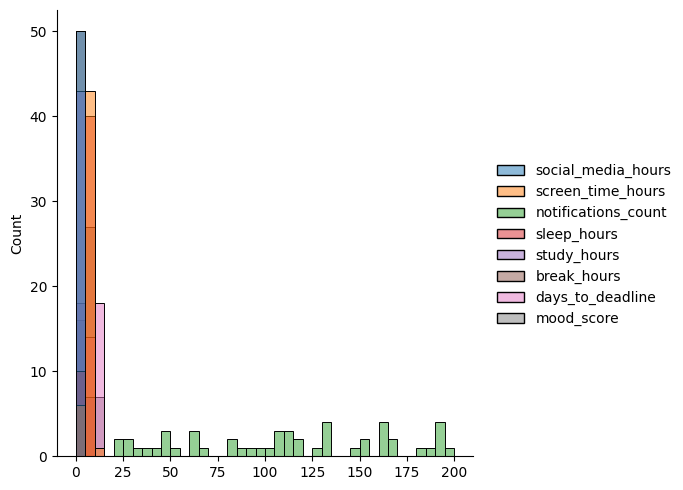

In [16]:
sns.displot(x)
plt.show()

C:\Users\aryan\AppData\Local\Temp\ipykernel_23236\2662093251.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y)


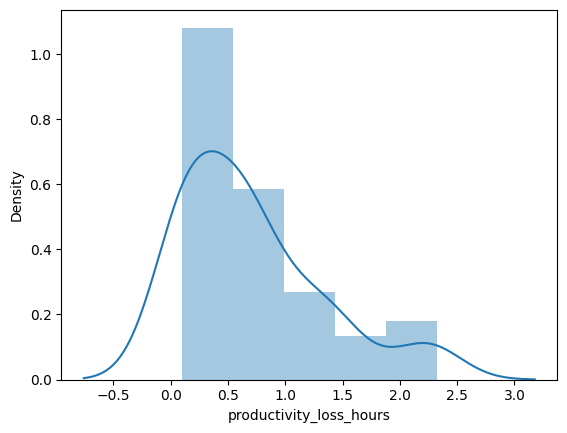

In [17]:
sns.distplot(y)
plt.show()

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(mae, rmse,r2)


0.1750393340772937 0.21991368239809644 0.8850559301953425


In [19]:
importance = pd.Series(lr.coef_, index=x.columns)
importance.sort_values(ascending=False)


break_hours            0.523582
social_media_hours     0.320636
screen_time_hours      0.014868
mood_score             0.011887
days_to_deadline       0.008427
notifications_count    0.003386
sleep_hours           -0.181744
study_hours           -0.234431
dtype: float64

# Using LAsso

In [20]:
from sklearn.linear_model import Lasso

In [21]:
ls = Lasso(alpha=0.1)
ls.fit(x_train,y_train)

Lasso(alpha=0.1)

In [22]:
ls_pred=ls.predict(x_test)

# using Ridge

In [23]:
from sklearn.linear_model import Ridge
ri = Ridge(alpha=0.1)

In [24]:
ri.fit(x_train,y_train)

Ridge(alpha=0.1)

In [25]:
ri_pred = ri.predict(x_test)

In [26]:
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)
mae_ls = mean_absolute_error(y_test, ls_pred)
rmse_ls = np.sqrt(mean_squared_error(y_test, ls_pred))
r2_ls = r2_score(y_test, ls_pred)
mae_ri = mean_absolute_error(y_test, ri_pred)
rmse_ri = np.sqrt(mean_squared_error(y_test, ri_pred))
r2_ri = r2_score(y_test, ri_pred)
print(mae_lr,rmse_lr,r2_lr)
print(mae_ls,rmse_ls,r2_ls)
print(mae_ri,rmse_ri,r2_ri)

0.1750393340772937 0.21991368239809644 0.8850559301953425
0.20522440601291475 0.28969198305179106 0.8005403641062518
0.1741829886571464 0.21835343917779498 0.8866811543342958


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
rf_pred
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

In [28]:
print(mae_lr,rmse_lr,r2_lr)
print(mae_ls,rmse_ls,r2_ls)
print(mae_ri,rmse_ri,r2_ri)
print(mae_rf,rmse_rf,r2_rf)

0.1750393340772937 0.21991368239809644 0.8850559301953425
0.20522440601291475 0.28969198305179106 0.8005403641062518
0.1741829886571464 0.21835343917779498 0.8866811543342958
0.35459 0.489488495268275 0.43053498802121937


# Final Model we are using Ridge 

In [29]:
from sklearn.linear_model import Ridge

final_model = Ridge(alpha=1.0)
final_model.fit(x_train, y_train)

Ridge()

In [30]:
y_pred = final_model.predict(x_test)


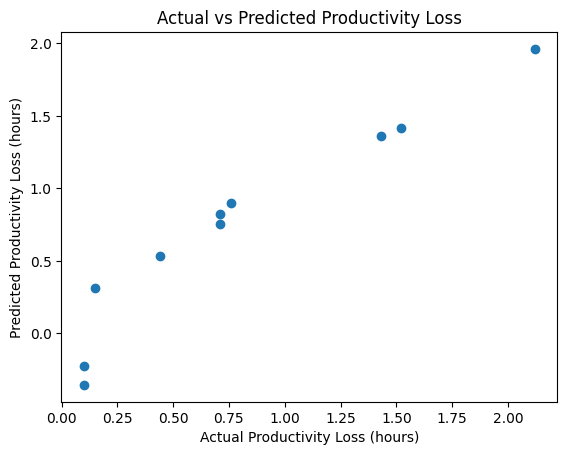

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Productivity Loss (hours)")
plt.ylabel("Predicted Productivity Loss (hours)")
plt.title("Actual vs Predicted Productivity Loss")
plt.show()


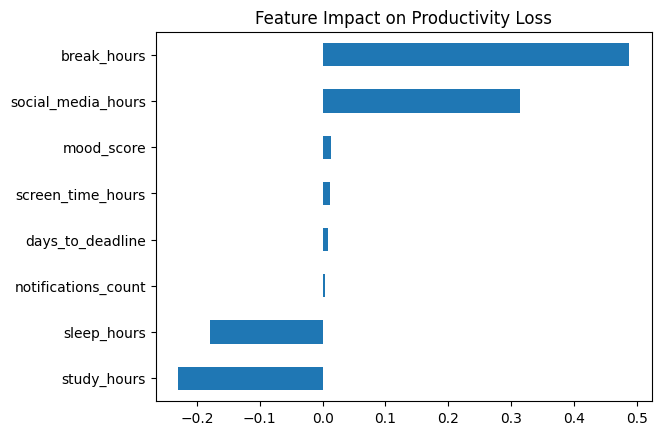

In [32]:
import pandas as pd

coefficients = pd.Series(final_model.coef_, index=x.columns)
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Impact on Productivity Loss")
plt.show()


# Deployin model

In [33]:
import pickle

with open("ridge_productivity_model.pkl", "wb") as file:
    pickle.dump(final_model, file)
